In [1]:
# 아래의 펭귄데이터가 있다.
# KNN 과 결정트리 모델을 사용 하여.
# 평가지표를 비교 하시오.

# 조건 : 전처리 및 정규화 과정을 거치시오.


# ==============================
# 📦 1. 라이브러리 로드
# ==============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# 🐧 2. 데이터 로드
# ==============================
df = sns.load_dataset("penguins")

print(df.head())
print(df.info())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  

In [2]:
display(df[df["bill_depth_mm"].isnull()])

# species, island를 제외하고 모두 다 null값을 가진 것이므로 2개 제외 판단


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df.drop(index=[3, 339])

In [4]:
# 엑셀 저장
df.to_excel("penguin.xlsx",index=False)

In [5]:
# 전처리
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["species"] = le.fit_transform(df['species'])
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,0,Torgersen,39.5,17.4,186.0,3800.0,Female
2,0,Torgersen,40.3,18.0,195.0,3250.0,Female
4,0,Torgersen,36.7,19.3,193.0,3450.0,Female
5,0,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,2,Biscoe,47.2,13.7,214.0,4925.0,Female
340,2,Biscoe,46.8,14.3,215.0,4850.0,Female
341,2,Biscoe,50.4,15.7,222.0,5750.0,Male
342,2,Biscoe,45.2,14.8,212.0,5200.0,Female


In [6]:
df.isnull().sum()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64

In [7]:
df['sex'] = df['sex'].mode()[0]

print(df)


     species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0          0  Torgersen            39.1           18.7              181.0   
1          0  Torgersen            39.5           17.4              186.0   
2          0  Torgersen            40.3           18.0              195.0   
4          0  Torgersen            36.7           19.3              193.0   
5          0  Torgersen            39.3           20.6              190.0   
..       ...        ...             ...            ...                ...   
338        2     Biscoe            47.2           13.7              214.0   
340        2     Biscoe            46.8           14.3              215.0   
341        2     Biscoe            50.4           15.7              222.0   
342        2     Biscoe            45.2           14.8              212.0   
343        2     Biscoe            49.9           16.1              213.0   

     body_mass_g   sex  
0         3750.0  Male  
1         3800.0  Male  


In [20]:
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])

In [21]:
X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
print(X_train)

X_test = scaler.transform(X_test)
print(X_test)

[[-0.90602883 -0.24041066  0.60354716 -0.37926138 -0.18011949  0.        ]
 [ 1.93702715 -1.79533121  0.50249327 -0.59143014 -0.93372288  0.        ]
 [ 0.51549916 -1.27099754 -0.30593789 -1.1572135  -1.0279233   0.        ]
 ...
 [-0.90602883 -1.05403188  1.46250527 -0.8035989  -0.39992048  0.        ]
 [-0.90602883  0.80825668 -1.51858463  1.31808871  1.35848743  0.        ]
 [-0.90602883 -1.12635376  1.46250527 -0.8035989   0.0396815   0.        ]]
[[-0.90602883  0.39240584 -1.31647684  0.54013659  0.7304846   0.        ]
 [ 1.93702715 -1.21675612  1.71514    -0.16709261 -0.55692118  0.        ]
 [-0.90602883 -0.80090528  1.8161939  -0.73287598 -0.39992048  0.        ]
 [ 0.51549916  0.01271594  1.31092442 -0.37926138  0.22808234  0.        ]
 [ 1.93702715 -0.45737632  0.60354716 -0.4499843   0.10248178  0.        ]
 [-0.90602883 -0.04152548 -1.61963852  0.46941367  0.10248178  0.        ]
 [ 0.51549916  1.83884355  1.86672084 -0.02564677  0.10248178  0.        ]
 [ 0.51549916  0.42

In [25]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train,y_train)

# 예측

pred = model.predict(X_test)
print(accuracy_score(y_test,pred))

1.0


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

model = DecisionTreeClassifier(random_state=42)  # 단점: 과적합

X = df.drop(columns=['species'])
y = df['species']

model.fit(X,y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

IndexError: list index out of range

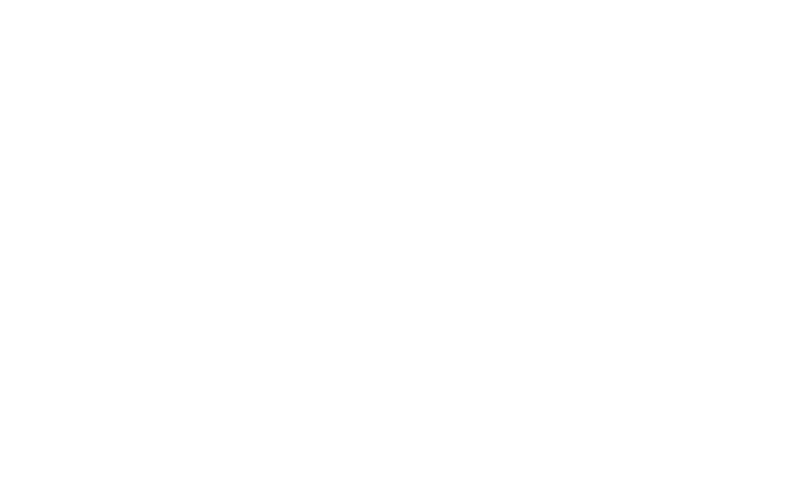

In [27]:
plt.figure(figsize=(10, 6))

plot_tree(
    model,
    # feature_names = X.columns,      # 컬럼명 표시
    feature_names = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm","body_mass_g"],
    class_names=["No", "Yes"],    # 0,1 이름 변경
    filled=True,                  # 색상
    rounded=True,                 # 둥근 모서리
    fontsize=12
)

plt.show()